In [2]:
import numpy as np
from itertools import cycle
import os

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import datetime as dt
import subprocess
from scipy.ndimage import binary_fill_holes
from importlib import reload
#! ADD DEV VERSIONS OF RMOM6
import sys
sys.path.insert(0, '/g/data/gb02/ab8992/regional-mom6/regional-mom6')
sys.path.insert(0, '/g/data/gb02/ab8992/regional-mom6/mom6_forge')
from pathlib import Path
import regional_mom6 as rm
from dask.distributed import Client
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/36095/status,
Dashboard: /proxy/36095/status,Workers: 7
Total threads: 28,Total memory: 112.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39195,Workers: 0
Dashboard: /proxy/36095/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37845,Total threads: 4
Dashboard: /proxy/37793/status,Memory: 16.00 GiB
Nanny: tcp://127.0.0.1:35417,


# TTide domain

In [2]:

## Choose your coordinates and the name of your experiment


yextent = [-56,-26]
xextent = [142,180]
expt_name = "full-20"

# 
daterange = ["2010-01-01 00:00:00", "2020-12-31 00:00:00"]

## Place where all your input files go
inputdir = f"/g/data/nm03/ab8992/ttide-inputs/reruns/{expt_name}/"

## Directory where you'll run the experiment from
rundir = f"/home/149/ab8992/tasman-tides/re-rundirs/{expt_name}/"

## Directory where raw downloads go before processing
tmpdir = Path(f"/g/data/nm03/ab8992/glorys-download/tenyears")
# tmpdir = f"/home/149/ab8992/tasman-tides/rundirs/full-20/inputdir/forcing"
# tmpdir = "/home/149/ab8992/tasman-tides/rundirs/mkic/archive/output000/"
## Directory where fre tools are stored
toolpath = "/g/data/ik11/mom6_tools/tools/bin/" ## Compiled tools needed for construction of mask tables
for i in [rundir,tmpdir,inputdir]:
    if not os.path.exists(i):
        subprocess.run(f"mkdir {i} -p",shell=True)

In [3]:
expt = rm.experiment(
    longitude_extent = xextent,
    latitude_extent = yextent,
    date_range = daterange,
    hgrid_type = "even_spacing",
    resolution = 0.05,  ## Resolution
    number_vertical_layers = 100,      ## #zlayers
    layer_thickness_ratio = 20,       ## dz ratio
    depth = 5500,    ## Max depth of ocean
    mom_run_dir = rundir,
    tidal_constituents = ["M2"],
    mom_input_dir = inputdir,
    boundaries=["north", "south", "east", "west"],
    # fms_path = toolpath
)

# expt = rmom6.experiment(
#     longitude_extent = longitude_extent,
#     latitude_extent = latitude_extent,
#     date_range = [date_range[0], date_range[1]],
#     hgrid_type = "from_file",
#     number_vertical_layers = 75,
#     layer_thickness_ratio = 20,
#     resolution = 0.1,
#     minimum_depth = 15,
#     depth = 4500,
#     tidal_constituents=[], # Uncomment to turn tides on! This can make the domain unstable though if you've chosen poor boundaries, so good to test first with no tides.
#     mom_run_dir = run_dir,
#     mom_input_dir = input_dir,
#     boundaries=["north", "south", "east", "west"]
# )

This means that some areas may only have one or two layers between the surface and sea floor. 
For increased stability, consider increasing the minimum depth, or adjusting the vertical coordinate to add more layers near the surface.


In [12]:
ocean_varnames = {"time": "time",
                  "yh": "latitude",
                  "xh": "longitude",
                  "zl": "depth",
                  "eta": "zos",
                  "u": "uo",
                  "v": "vo",
                  "tracers": {"salt": "so", "temp": "thetao"}
                  }

# Set up the initial condition.
expt.setup_initial_condition(
    tmpdir / "ic_unprocessed.nc", # directory where the unprocessed initial condition is stored, as defined earlier
    ocean_varnames,
    arakawa_grid = "A"
    )

# Set up the four boundary conditions.
expt.setup_ocean_state_boundaries(
    Path(tmpdir),
    ocean_varnames,
    arakawa_grid = "A"
    )

Applying Arakawa A grid variable mapping, which is velocities and tracers on the same grid


INFO:regional_mom6.utils:Units for depth did not need to be converted
INFO:regional_mom6.utils:Units for eta did not need to be converted
INFO:regional_mom6.regridding:Getting t points..
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Creating Regridder


Setting up Initial Conditions
Regridding Velocities... 

INFO:regional_mom6.rotation:Getting rotation angle
INFO:regional_mom6.rotation:Calculating grid rotation angle
INFO:regional_mom6.regridding:Getting u points..
INFO:regional_mom6.regridding:Getting v points..


Done.
Regridding Tracers... Done.
Regridding Free surface... Done.
Saving outputs... 

...

Done.
Processing east boundary velocity & tracers...Applying Arakawa A grid variable mapping, which is velocities and tracers on the same grid


INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.utils:Units for depth did not need to be converted
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.rotation:Getting rotation angle
INFO:regional_mom6.rotation:Calculating grid rotation angle
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Adding time dimension
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in salt_segment_003
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to salt_segment_003
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in temp_segment_003
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to temp_segment_003
INFO:regional_mom6.regridding:Renaming ver

Done.
Processing west boundary velocity & tracers...Applying Arakawa A grid variable mapping, which is velocities and tracers on the same grid


INFO:regional_mom6.utils:Units for depth did not need to be converted
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.rotation:Getting rotation angle
INFO:regional_mom6.rotation:Calculating grid rotation angle
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Adding time dimension
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in salt_segment_004
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to salt_segment_004
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in temp_segment_004
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to temp_segment_004
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in u_segment_004
INFO:regional_mom6.regridding:Replac

Done.


In [ ]:
expt.setup_era5("/g/data/ik11/inputs/ERA5/single-levels/reanalysis/")


Setting up bathymetry...if this fails, please follow the printed instructions with your experiment topo object, like this: [experiment_obj].topo. For example, if the output tells you to run mpi_set_from_dataset instead of set_from_dataset. You would do: [experiment_obj].topo.mpi_set_from_dataset(...)
**NOTE**
            If bathymetry setup fails (e.g. kernel crashes), restart the kernel and edit this cell.
            Call ``[topo_object_name].mpi_set_from_dataset()`` instead. Follow the given instructions for using mpi
            and ESMF_Regrid outside of a python environment. This breaks up the process, so be sure to call
            ``[topo_object_name].tidy_dataset() after regridding with mpi.
Begin regridding dataset...

Original dataset size: 557.24 Mb
Regridded size: 14.50 Mb

Tidy bathymetry: Reading in regridded bathymetry to fix up metadata...done. Filling in inland lakes and channels... 

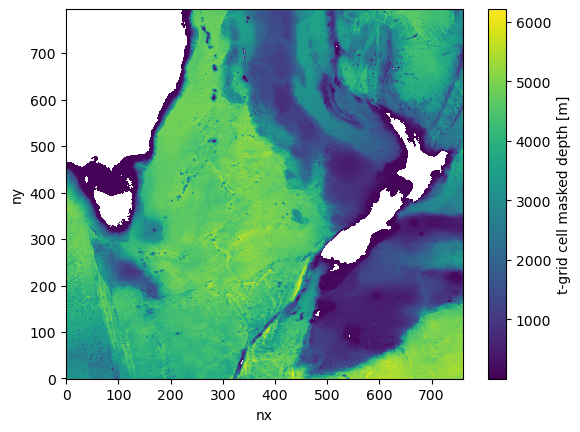

In [15]:
# expt.bathymetry(
#     '/g/data/nm03/ab8992/synbath2/SYNBATH_V1.2.nc',
#     {"xh":"lon",
#      "yh":"lat",
#      "elevation":"z"}, ## Again this dictionary just maps mom6 variable names to what they are in your topog.
#      minimum_layers = 1,
#     #  maketopog=False
#     )

expt.setup_bathymetry(
    bathymetry_path='/g/data/nm03/ab8992/synbath2/SYNBATH_V1.2.nc',
    longitude_coordinate_name='lon',
    latitude_coordinate_name='lat',
    vertical_coordinate_name='z',
    )
expt.bathymetry.depth.where(expt.bathymetry.depth != 0).plot() #TODO add 0 as fill value in rmom6 so that it plots nicely without this ugly step

In [18]:
expt.setup_boundary_tides("/g/data/nm03/TPXO9v5a/h_tpxo9.v5a.nc","/g/data/nm03/TPXO9v5a/u_tpxo9.v5a.nc",tidal_constituents=["M2"])

INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Creating Regridder


Processing north boundary...

INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Adding time dimension
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Adding perpendicular dimension to zamp_segment_001
INFO:regional_mom6.regridding:Adding perpendicular dimension to zphase_segment_001
INFO:regional_mom6.regridding:Generating encoding dictionary
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.rotation:Getting rotat

Done
Processing south boundary...

INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Adding time dimension
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Adding perpendicular dimension to zamp_segment_002
INFO:regional_mom6.regridding:Adding perpendicular dimension to zphase_segment_002
INFO:regional_mom6.regridding:Generating encoding dictionary
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.rotation:Getting rotat

Done
Processing east boundary...

INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Adding time dimension
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Adding perpendicular dimension to zamp_segment_003
INFO:regional_mom6.regridding:Adding perpendicular dimension to zphase_segment_003
INFO:regional_mom6.regridding:Generating encoding dictionary
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.rotation:Getting rotat

Done
Processing west boundary...

INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Adding time dimension
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Adding perpendicular dimension to zamp_segment_004
INFO:regional_mom6.regridding:Adding perpendicular dimension to zphase_segment_004
INFO:regional_mom6.regridding:Generating encoding dictionary
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.rotation:Getting rotat

Done


In [4]:
expt.setup_fms_version(ncpus = 104 * 3)

Could not find premade run directories at  /g/data/gb02/ab8992/regional-mom6/regional-mom6/regional_mom6/demos/premade_run_directories
Perhaps the package was imported directly rather than installed with conda. Checking if this is the case... Found run files. Continuing...
Added MINIMUM_DEPTH to MOM_override with value {'value': 4.0, 'override': True, 'comment': None}
Added NK to MOM_override with value {'value': 100, 'override': True, 'comment': None}
Added NIGLOBAL to MOM_override with value {'value': 760, 'override': True, 'comment': None}
Added NJGLOBAL to MOM_override with value {'value': 795, 'override': True, 'comment': None}
Added AUTO_MASKTABLE to MOM_override with value {'value': True, 'override': True, 'comment': None}
Added OBC_NUMBER_OF_SEGMENTS to MOM_override with value {'value': 4, 'override': True, 'comment': None}
Added OBC_FREESLIP_VORTICITY to MOM_override with value {'value': 'False', 'override': True, 'comment': None}
Added OBC_FREESLIP_STRAIN to MOM_override with

In [23]:
expt.fre_tools_dir = Path("/g/data/ik11/mom6_tools/tools/bin/")
expt.run_FRE_tools()


Running GFDL's FRE Tools. The following information is all printed by the FRE tools themselves
NOTE from make_solo_mosaic: there are 0 contacts (align-contact)
congradulation: You have successfully run make_solo_mosaic
OUTPUT FROM MAKE SOLO MOSAIC:

CompletedProcess(args='/g/data/ik11/mom6_tools/tools/bin/make_solo_mosaic --num_tiles 1 --dir . --mosaic_name ocean_mosaic --tile_file hgrid.nc', returncode=0)


cp: './ocean_mosaic.nc' and 'ocean_mosaic.nc' are the same file
cp: './hgrid.nc' and 'hgrid.nc' are the same file


cp ./hgrid.nc hgrid.nc 

NOTE from make_coupler_mosaic: the ocean land/sea mask will be determined by field depth from file bathymetry.nc
mosaic_file is grid_spec.nc

***** Congratulation! You have successfully run make_quick_mosaic
OUTPUT FROM QUICK MOSAIC:

CompletedProcess(args='/g/data/ik11/mom6_tools/tools/bin/make_quick_mosaic --input_mosaic ocean_mosaic.nc --mosaic_name grid_spec --ocean_topog bathymetry.nc', returncode=0)


In [8]:
expt.setup_run_directory("",using_payu=True)

Number of CPUs required:  1435


## Add Tides to an Existing Run
Offline I've copied all the inputs from the ttide-20 run. All that this notebook does is use the out-of-the-box NWA scripts to add tidal constituents. I'll then need to go back to the MOM_input file from my old tide test to rectify the new one 

In [4]:
import os
import xarray as xr
os.chdir("/home/149/ab8992/cosima_regional/development/withtides/regional-mom6/")
os.listdir()
import boundary_tides as bt

In [8]:
## VERBATIM COPY OLD CODE AND SEE WHAT HAPPENS

# """
# constituents in TPXO9:
# con =
# "m2  ",  0
# "s2  ",  1
# "n2  ",  2
# "k2  ",  3
# "k1  ",  4
# "o1  ",  5
# "p1  ",  6
# "q1  ",  7
# "mm  ",  8
# "mf  ",  9
# "m4  ", 10
# "mn4 ", 11
# "ms4 ", 12
# "2n2 ", 13
# "s1  "  14
# """
# Use these constituents:
# (MOM6 does not currently support m4, mn4, ms4, 2n2, or s1.)
# constituents = range(0, 10)

constituents = [0]

# Hardcoded for my ttide domain!!! 

horizontal_subset = dict(ny=slice(200,380), nx=slice(850,1100))

# Path to tpxo9.v1 data
tpxo_dir = '/g/data/nm03/TPXO'

# Save output here
output_dir = inputdir + "/forcing"

# Setup NWA boundaries
hgrid = xr.open_dataset(inputdir + '/hgrid.nc')
# segments taken from nwa25_obc.py
segments = [
    bt.Segment(1, 'south', hgrid, output_dir=output_dir),
    bt.Segment(2, 'north', hgrid, output_dir=output_dir),
    bt.Segment(3, 'west', hgrid, output_dir=output_dir),
    bt.Segment(4, 'east', hgrid, output_dir=output_dir)
]
# reload(bt)
bt.write_tpxo(constituents, tpxo_dir, segments, horizontal_subset,"tpxo9.v1.nc")

## Regrid era


In [9]:
expt.daterange[0].year

2015

In [12]:
ls /g/data/

hh5/  nm03/  v45/  x77/
